In [4]:
from pathlib import Path
import skfuzzy as fuzz
import pandas as pd
import numpy as np

LOCAL_FOLDER = Path.cwd().parent.parent / "local_folder"
df = pd.read_csv(LOCAL_FOLDER / 'aggregated_company_data.csv')

In [5]:
RESOLUTION = 1000
MIN_QUANTILE = 0.05
MAX_QUANTILE = 0.95

LOW_QUANTILE = 0.25
MID_QUANTILE = 0.5
HIGH_QUANTILE = 0.75

c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


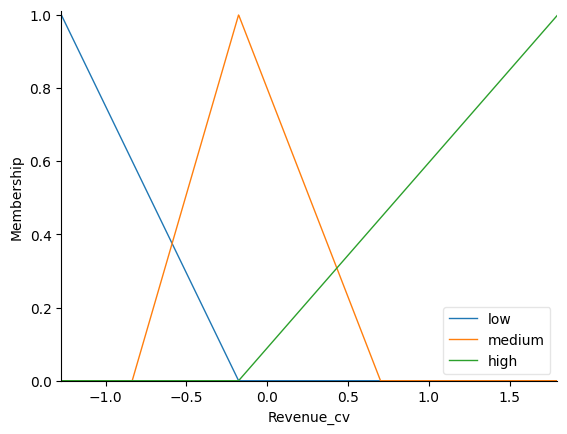

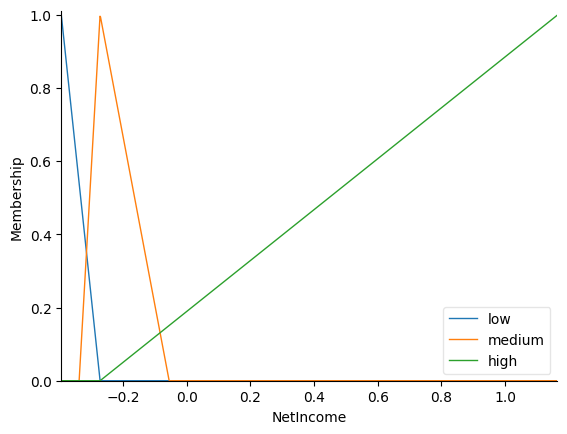

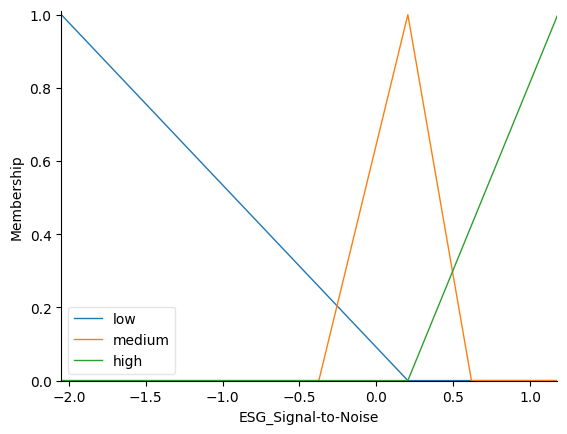

In [6]:
from skfuzzy import control as ctrl

METRIC_NAMES = ['Revenue_cv', 'NetIncome', 'ESG_Signal-to-Noise']
# metryki, które IM NIŻSZE TYM LEPSZE
REVERSED_METRICS = [] 

METRICS = {}

for name in METRIC_NAMES:

    min_val = df[name].quantile(MIN_QUANTILE)
    max_val = df[name].quantile(MAX_QUANTILE)
    step = (max_val - min_val) / RESOLUTION
    array = np.arange(min_val, max_val, step)
    antecedent = ctrl.Antecedent(array, name)
    is_reversed = name in REVERSED_METRICS

    q_min = min_val
    q_low = df[name].quantile(LOW_QUANTILE)
    q_mid = df[name].quantile(MID_QUANTILE)
    q_high = df[name].quantile(HIGH_QUANTILE)
    q_max = max_val
    
    # 2. Automatyczne generowanie trójkątów (Fuzzy Sets)
    if is_reversed:
        antecedent['high'] = fuzz.trimf(array, [q_min, q_min, q_mid])
        antecedent['medium'] = fuzz.trimf(array, [q_low, q_mid, q_high])
        antecedent['low'] = fuzz.trimf(array, [q_mid, q_max, q_max])
    else:
        antecedent['low'] = fuzz.trimf(array, [q_min, q_min, q_mid])
        antecedent['medium'] = fuzz.trimf(array, [q_low, q_mid, q_high])
        antecedent['high'] = fuzz.trimf(array, [q_mid, q_max, q_max])
    
    # 3. Zapis do słownika
    METRICS[name] = {
        "NAME": name,
        "MIN_VAL": min_val,
        "MAX_VAL": max_val,
        "STEP": step,
        "ARRAY": array,
        "ANTECEDENT": antecedent,
        "IS_REVERSED": is_reversed
    }

    antecedent.view()

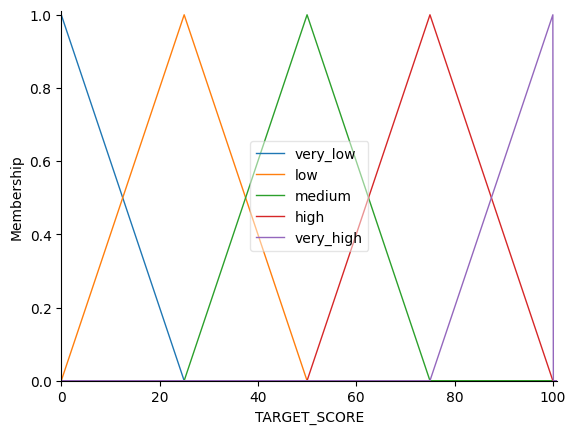

In [7]:
TARGET_SCORE = ctrl.Consequent(np.arange(0, 101, 0.1), 'TARGET_SCORE')
universe_target = TARGET_SCORE.universe

# Zastępujemy Gaussy trójkątami dla prawidłowego środka ciężkości
TARGET_SCORE['very_low'] = fuzz.trimf(universe_target, [0, 0, 25])
TARGET_SCORE['low'] = fuzz.trimf(universe_target, [0, 25, 50])
TARGET_SCORE['medium'] = fuzz.trimf(universe_target, [25, 50, 75])
TARGET_SCORE['high'] = fuzz.trimf(universe_target, [50, 75, 100])
TARGET_SCORE['very_high'] = fuzz.trimf(universe_target, [75, 100, 100])

TARGET_SCORE.view()

In [8]:
rules = []
import itertools

# Wyciągnięcie gotowych zmiennych ze słownika
metric1_antecedent = METRICS['Revenue_cv']['ANTECEDENT']
metric2_antecedent = METRICS['NetIncome']['ANTECEDENT']
metric3_antecedent = METRICS['ESG_Signal-to-Noise']['ANTECEDENT']

points_map = {'low': 1, 'medium': 3, 'high': 5}

score_to_label = {
    3: 'very_low',
    5: 'low',
    7: 'low',
    9: 'medium',
    11: 'high',
    13: 'high',
    15: 'very_high' 
}

states = ['low', 'medium', 'high']
rules = []

# itertools.product generuje wszystkie 27 kombinacji (3x3x3)
for state_m1, state_m2, state_m3 in itertools.product(states, repeat=3):
    
    total_points = points_map[state_m1] + points_map[state_m2] + points_map[state_m3]
    
    target_label = score_to_label[total_points]
    
    rule = ctrl.Rule(
        metric1_antecedent[state_m1] & metric2_antecedent[state_m2] & metric3_antecedent[state_m3], 
        TARGET_SCORE[target_label]
    )
    rules.append(rule)

print(f"Wygenerowano {len(rules)} reguł zgodnie z nową punktacją (1, 3, 5).")

Wygenerowano 27 reguł zgodnie z nową punktacją (1, 3, 5).


In [9]:
import numpy as np
from pathlib import Path

SCORING_CTRL = ctrl.ControlSystem(rules)
scoring_sim = ctrl.ControlSystemSimulation(SCORING_CTRL)

target_scores = []

for index, row in df.iterrows():
    try:
        # Po lewej stronie: klucze użyte w ctrl.Antecedent(..., 'KLUCZ')
        # Po prawej stronie: faktyczne wartości z kolumn Twojego DataFrame (df)
        
        scoring_sim.input['Revenue_cv'] = row['Revenue_cv']
        scoring_sim.input['NetIncome'] = row['NetIncome']
        scoring_sim.input['ESG_Signal-to-Noise'] = row['ESG_Signal-to-Noise']

        scoring_sim.compute()
        score = scoring_sim.output['TARGET_SCORE']

        target_scores.append(round(score, 2))
        print(f"[{index + 1}/{len(df)}] Firma: {row['CompanyName']:<20} | Score: {score:.2f}")
        
    except Exception as e:
        # Obsługa błędów: jeśli w wierszu brakuje danych (np. NaN z powodu dzielenia przez zero), 
        print(f"!!! Błąd przy firmie {row['CompanyName']}: {e}")
        target_scores.append(np.nan)

df['TARGET_SCORE'] = target_scores

output_filename = LOCAL_FOLDER / 'scored_company_data_PCA_RULES.csv'
df.to_csv(output_filename, index=False)

print("-" * 50)
print(f"Sukces! Symulacja zakończona dla {len(df)} firm.")
print(f"Wyniki zostały zapisane do pliku: {output_filename}")

# (Opcjonalnie) Wyświetlenie top 5 najlepiej ocenionych firm prosto w Notebooku
df_sorted = df.sort_values(by='TARGET_SCORE', ascending=False)
display(df_sorted[['CompanyName', 'TARGET_SCORE']].head(20))

[1/1000] Firma: Company_1            | Score: 25.01
[2/1000] Firma: Company_2            | Score: 39.33
[3/1000] Firma: Company_3            | Score: 24.00
[4/1000] Firma: Company_4            | Score: 75.00
[5/1000] Firma: Company_5            | Score: 25.00
[6/1000] Firma: Company_6            | Score: 24.49
[7/1000] Firma: Company_7            | Score: 25.00
[8/1000] Firma: Company_8            | Score: 75.00
[9/1000] Firma: Company_9            | Score: 52.01
[10/1000] Firma: Company_10           | Score: 90.02
[11/1000] Firma: Company_11           | Score: 75.00
[12/1000] Firma: Company_12           | Score: 72.35
[13/1000] Firma: Company_13           | Score: 60.44
[14/1000] Firma: Company_14           | Score: 45.76
[15/1000] Firma: Company_15           | Score: 74.96
[16/1000] Firma: Company_16           | Score: 53.57
[17/1000] Firma: Company_17           | Score: 73.13
[18/1000] Firma: Company_18           | Score: 75.27
[19/1000] Firma: Company_19           | Score: 67.55
[2

,CompanyName,TARGET_SCORE
827,Company_828,91.70
461,Company_462,91.61
75,Company_76,91.36
807,Company_808,91.09
645,Company_646,91.01
371,Company_372,90.84
284,Company_285,90.70
372,Company_373,90.56
763,Company_764,90.55
292,Company_293,90.55
